In [ ]:
import pandas as pd
df = pd.read_csv(r"data/raw/data.csv")

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [ ]:
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'], errors='coerce')

print("Shape of data",df.shape)
print(df.dtypes)

# Check null values
print("Null Values")
print(df.isnull().sum())

Shape of data (95662, 16)
TransactionId                        object
BatchId                              object
AccountId                            object
SubscriptionId                       object
CustomerId                           object
CurrencyCode                         object
CountryCode                           int64
ProviderId                           object
ProductId                            object
ProductCategory                      object
ChannelId                            object
Amount                              float64
Value                                 int64
TransactionStartTime    datetime64[ns, UTC]
PricingStrategy                       int64
FraudResult                           int64
dtype: object
Null Values
TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCat

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# Summary statistics
print(df[['Amount', 'Value']].describe())
print('*********************************')

# Central Tendency
print("Mean Amount:", df['Amount'].mean())
print("Median Amount:", df['Amount'].median())
print("Mode Amount:", df['Amount'].mode()[0])
print('////////////////////////////////////')
print("Mean Value:", df['Value'].mean())
print("Median Value:", df['Value'].median())
print("Mode Value:", df['Value'].mode()[0])
print('*********************************')

# Dispersion
print("Std Dev Amount:", df['Amount'].std())
print("IQR Amount:", df['Amount'].quantile(0.75) - df['Amount'].quantile(0.25))
print('////////////////////////////////////')
print("Std Dev Value:", df['Value'].std())
print("IQR Value:", df['Value'].quantile(0.75) - df['Value'].quantile(0.25))
print('*********************************')

# Skewness and Kurtosis
print("Skewness:", df['Amount'].skew())
print("Kurtosis:", df['Amount'].kurt())


             Amount         Value
count  9.566200e+04  9.566200e+04
mean   6.717846e+03  9.900584e+03
std    1.233068e+05  1.231221e+05
min   -1.000000e+06  2.000000e+00
25%   -5.000000e+01  2.750000e+02
50%    1.000000e+03  1.000000e+03
75%    2.800000e+03  5.000000e+03
max    9.880000e+06  9.880000e+06
*********************************
Mean Amount: 6717.846433275491
Median Amount: 1000.0
Mode Amount: 1000.0
////////////////////////////////////
Mean Value: 9900.583941376932
Median Value: 1000.0
Mode Value: 1000
*********************************
Std Dev Amount: 123306.79716433848
IQR Amount: 2850.0
////////////////////////////////////
Std Dev Value: 123122.08777619712
IQR Value: 4725.0
*********************************
Skewness: 51.098489522819115
Kurtosis: 3363.1277386950474


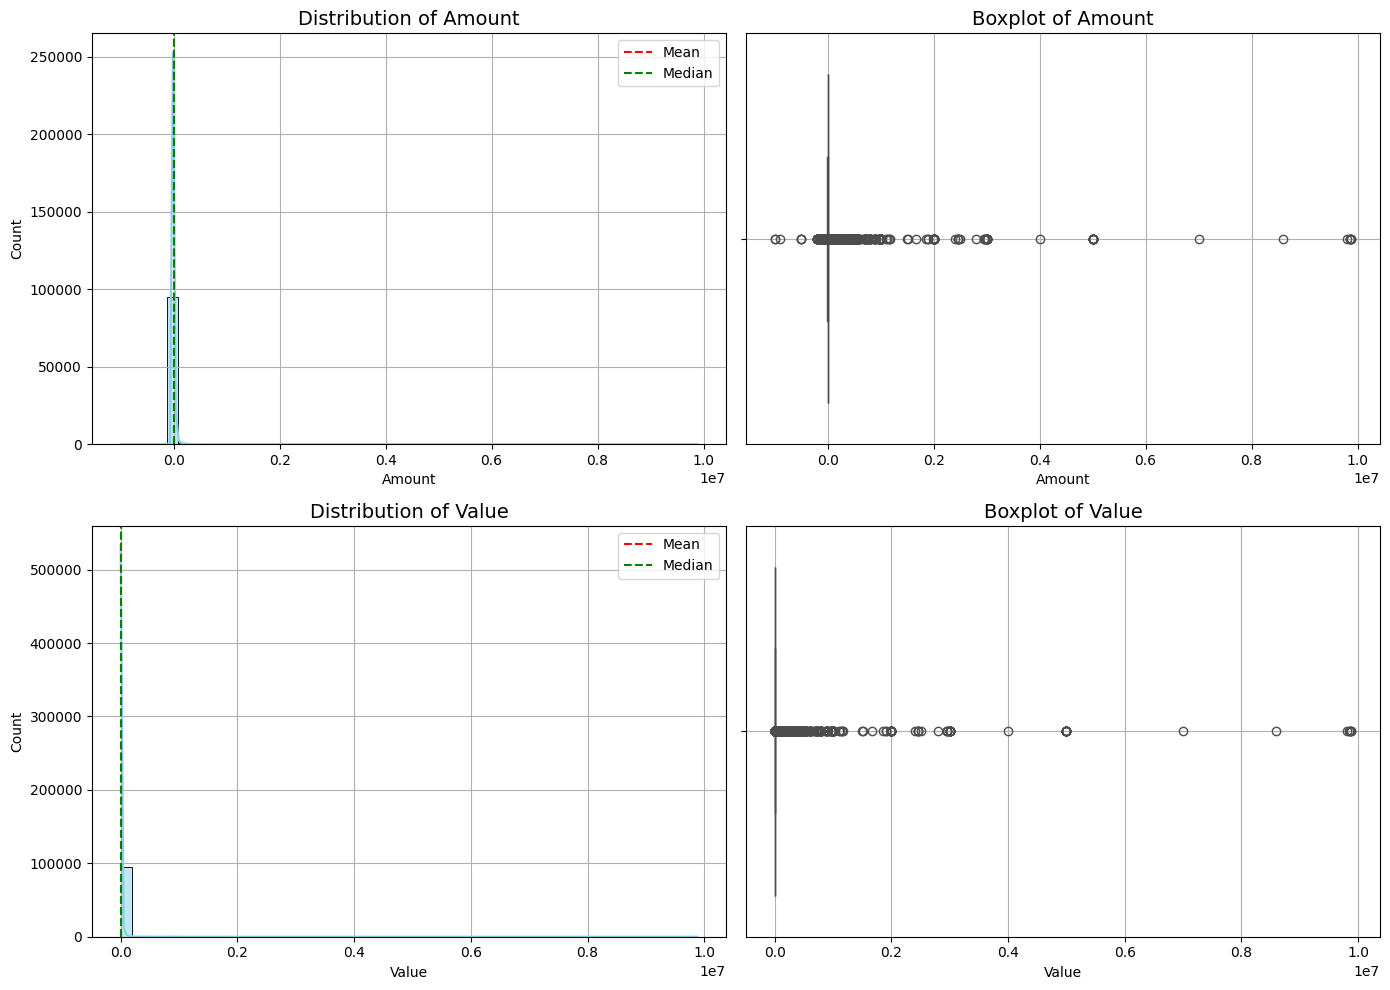

In [ ]:
# Filter numerical columns
numerical_cols = ['Amount', 'Value']  

# Create subplots
fig, axes = plt.subplots(nrows=len(numerical_cols), ncols=2, figsize=(14, 5 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    # Histogram + KDE
    sns.histplot(df[col].dropna(), bins=50, kde=True, ax=axes[i, 0], color='skyblue', edgecolor='black')
    axes[i, 0].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i, 0].axvline(df[col].median(), color='green', linestyle='--', label='Median')
    axes[i, 0].set_title(f"Distribution of {col}", fontsize=14)
    axes[i, 0].legend()
    axes[i, 0].grid(True)

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='orange')
    axes[i, 1].set_title(f"Boxplot of {col}", fontsize=14)
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()


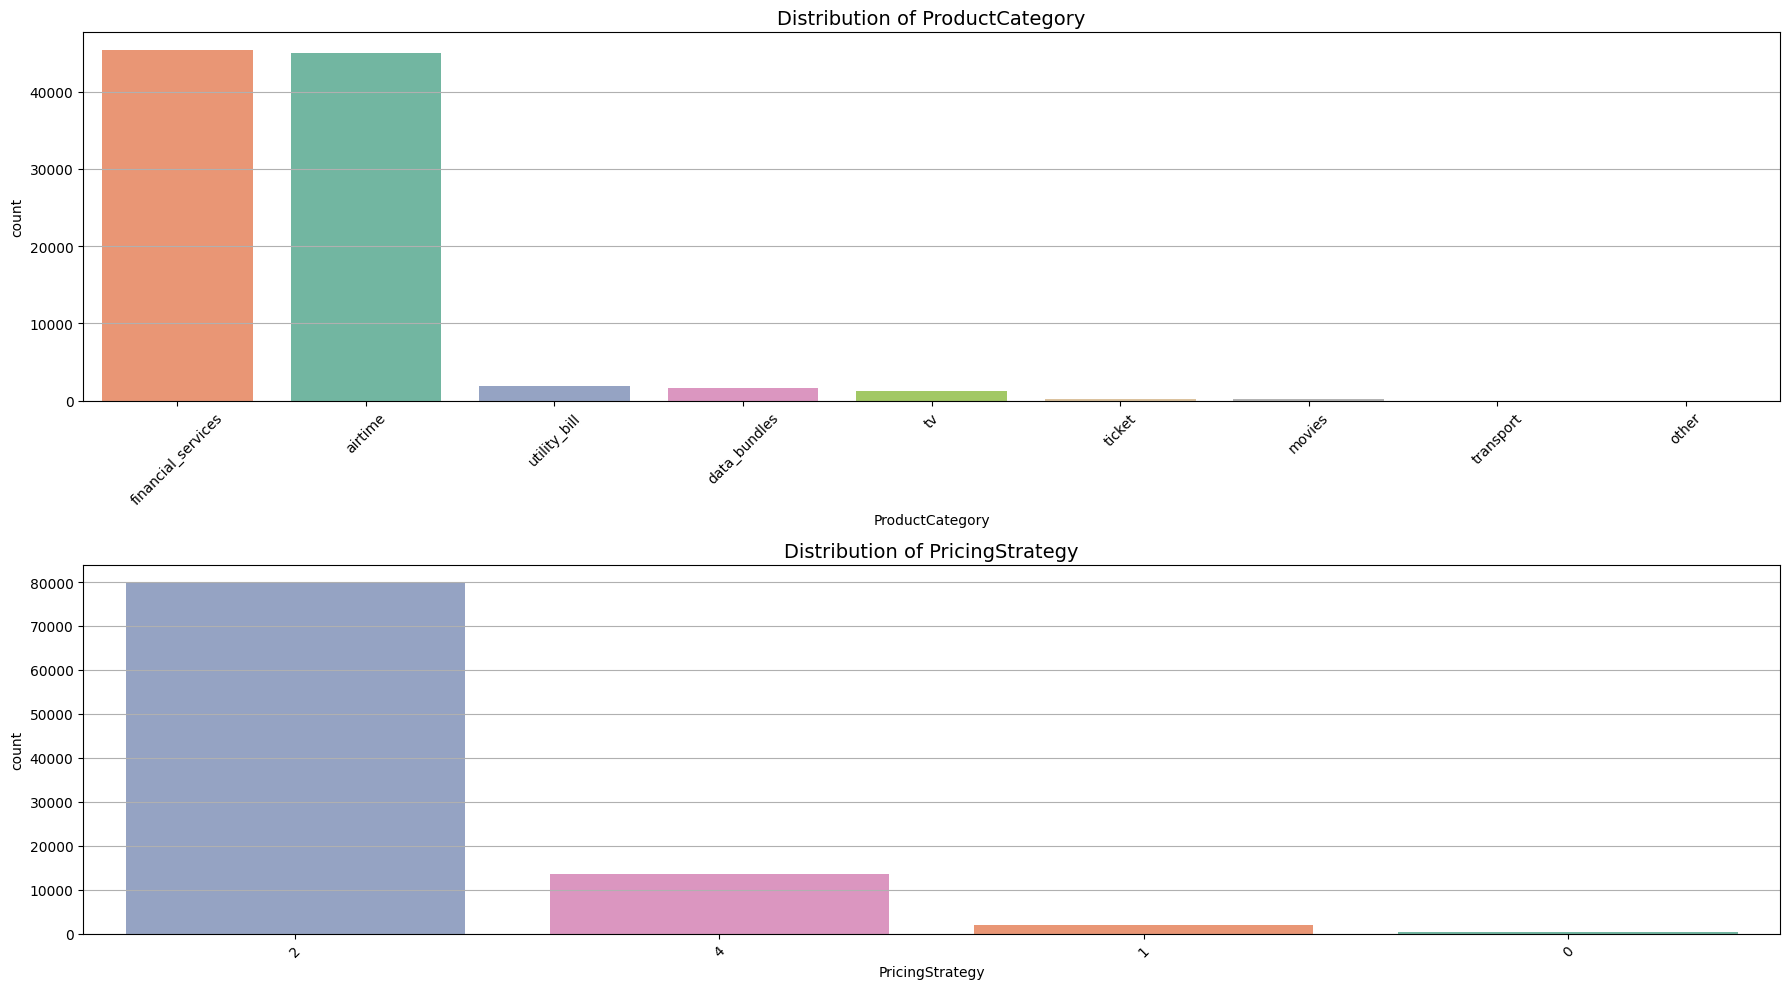

In [48]:
# List of selected categorical columns
categorical_cols = ['ProductCategory', 'PricingStrategy']

# Plot count plots
plt.figure(figsize=(18, 5 * len(categorical_cols)))

for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols), 1, i+1)
    sns.countplot(data=df, x=col, hue=col, order=df[col].value_counts().index, palette='Set2', legend=False)
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xticks(rotation=45)
    plt.grid(axis='y')

plt.tight_layout()
plt.show()


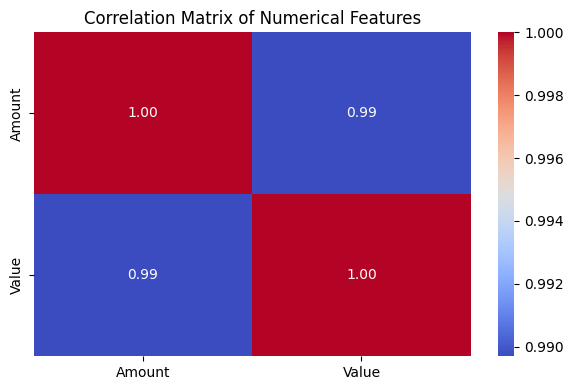

In [51]:
numerical_features = df[['Amount', 'Value']]  

corr_matrix = numerical_features.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()